# Portfolio Optimization - Walk-Forward Backtest

Goal: Roll the LP model forward quarter by quarter across the full 10-year dataset, collecting realized returns, tracking portfolio evolution, and computing performance metrics against benchmarks

In [4]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import pulp
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f'PuLP {pulp.__version__} ready.')

PuLP 3.3.0 ready.


### Load Data

In [8]:
returns = pd.read_csv('/Users/scottkeighley/MSDS 460/final_project_data/monthly_returns.csv', index_col=0, parse_dates=True)
prices = pd.read_csv('/Users/scottkeighley/MSDS 460/final_project_data/monthly_prices.csv', index_col=0, parse_dates=True)
meta = pd.read_csv('/Users/scottkeighley/MSDS 460/final_project_data/ticker_metadata.csv')

TICKERS = list(returns.columns)
TICKER_SECTOR = dict(zip(meta['ticker'], meta['sector']))
SECTORS = meta['sector'].unique().tolist()
N = len(TICKERS)
T = len(returns)

print(f'Assets: {N}')
print(f'Months: {T} ({returns.index[0].date()} -> {returns.index[-1].date()})')

Assets: 30
Months: 119 (2016-06-01 -> 2026-04-01)


### Parameters

In [14]:
TRAIN_MONTHS = 36
REBAL_MONTHS = 3
W_MAX = 0.15
SECTOR_MAX = 0.40
TURNOVER_MAX = 0.50
COST_BPS = 0.001

n_periods = (T - TRAIN_MONTHS) // REBAL_MONTHS
print(f'Walk-forward periods: {n_periods} quarters')
print(f'Backtest window: {returns.index[TRAIN_MONTHS].date()} -> {returns.index[-1].date()}')

Walk-forward periods: 27 quarters
Backtest window: 2019-06-01 -> 2026-04-01


### LP Solver (From LP Notebook)

In [16]:
def solve_lp(train_returns, w_prev, tickers, ticker_sector, sectors, 
             w_max=W_MAX, sector_max=SECTOR_MAX, 
             turnover_max=TURNOVER_MAX, cost_bps=COST_BPS):
    n = len(tickers)
    mu = train_returns.mean().values
    prob = pulp.LpProblem("PortfolioLP", pulp.LpMaximize)
    w = [pulp.LpVariable(f"w_{t}", lowBound=0, upBound=w_max) for t in tickers]
    z = [pulp.LpVariable(f"z_{t}", lowBound=0) for t in tickers]
    prob += (pulp.lpSum(mu[i]*w[i] for i in range(n))
             - cost_bps * pulp.lpSum(z[i] for i in range(n)))
    prob += pulp.lpSum(w) == 1
    for sector in sectors:
        idx = [i for i, t in enumerate(tickers) if ticker_sector.get(t) == sector]
        if idx:
            prob += pulp.lpSum(w[i] for i in idx) <= sector_max
    for i in range(n):
        prob += z[i] >= w[i] - w_prev[i]
        prob += z[i] >= w_prev[i] - w[i]
    prob += pulp.lpSum(z) <= turnover_max
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    weights = np.clip([pulp.value(w[i]) for i in range(n)], 0, None)
    weights /= weights.sum()
    return {
        'weights'    : weights,
        'status'     : pulp.LpStatus[prob.status],
        'exp_return' : float(mu @ weights),
        'turnover'   : float(np.sum(np.abs(weights - w_prev))),
        'tx_cost'    : float(np.sum(np.abs(weights - w_prev)) * cost_bps)
    }

print('solve_lp() ready.')

solve_lp() ready.


### Walk-Forward Loop

For each quarter: 
1. Train the LP on the most recent 36 months
2. Record optimal weights / diagnostics
3. Apply those weights to the next 3 months (test window)
4. Deduct transaction costs from the first months of each test period
5. Slide window forward and repeat

In [23]:
period_records = []
monthly_records = []
weights_history = []

w_prev = np.ones(N) / N

print('Running walk-forward backtest')

for p in range(n_periods):
    # Index bounds
    train_start = p * REBAL_MONTHS
    train_end = train_start + TRAIN_MONTHS
    test_start = train_end
    test_end = min(test_start + REBAL_MONTHS, T)

    train_ret = returns.iloc[train_start:train_end]
    test_ret = returns.iloc[test_start:test_end]

    # Solve LP
    sol = solve_lp(train_ret, w_prev, TICKERS, TICKER_SECTOR, SECTORS)

    # Realized monthly returns during test window
    port_monthly = test_ret.values @ sol['weights']
    port_monthly[0] -= sol['tx_cost']

    # Equal-weight benchmark (same 30 assets, rebalanced quarterly)
    ew_monthly = test_ret.values @ (np.ones(N) / N)

    # Period-level record
    period_records.append({
        'period': p + 1,
        'train_start': returns.index[train_start],
        'train_end': returns.index[train_end - 1],
        'test_start': returns.index[test_start],
        'test_end': returns.index[test_end - 1],
        'status': sol['status'],
        'exp_return_ann': sol['exp_return'] * 12,
        'realized_ret_ann': float(np.mean(port_monthly) * 12),
        'realized_ret_total': float((1 + port_monthly).prod() - 1),
        'ew_ret_ann': float(np.mean(ew_monthly) * 12),
        'ew_ret_total': float((1 + ew_monthly).prod() - 1),
        'turnover': sol['turnover'],
        'tx_cost_bps': sol['tx_cost'] * 10000,
        'n_assets': int((sol['weights'] > 0.001).sum())
    })

    # Monthly returns
    for m_idx, date in enumerate(test_ret.index):
        monthly_records.append({
            'date': date,
            'lp_return': port_monthly[m_idx],
            'ew_return': ew_monthly[m_idx],
            'period': p + 1
        })

    # Store weights
    weights_history.append(
        pd.Series(sol['weights'], index=TICKERS, name=returns.index[test_start])
    )

    w_prev = sol['weights'].copy()

# Assemble dataframes
periods_df = pd.DataFrame(period_records).set_index('period')
monthly_df = pd.DataFrame(monthly_records).set_index('date')
weights_df = pd.DataFrame(weights_history)

# Cumulative value series
monthly_df['lp_cum'] = (1 + monthly_df['lp_return']).cumprod()
monthly_df['ew_cum'] = (1 + monthly_df['ew_return']).cumprod()

print(f'Done. {n_periods} periods solved - all optimal: {(periods_df["status"]=="Optimal").all()}')
print(f'Backtest: {monthly_df.index[0].date()} -> {monthly_df.index[-1].date()}')
print(f'LP final portfolio value: ${monthly_df["lp_cum"].iloc[-1]:.4f} (started at $1.00)')
print(f'EW final portfolio value: ${monthly_df["ew_cum"].iloc[-1]:.4f} (started at $1.00)')

Running walk-forward backtest
Done. 27 periods solved - all optimal: True
Backtest: 2019-06-01 -> 2026-02-01
LP final portfolio value: $5.9804 (started at $1.00)
EW final portfolio value: $3.7518 (started at $1.00)


#### LP Nearly Double's EW's Terminal Value

Over the same ~7 year backtest window, on the same 30 assets: 

| | LP Portfolio | Equal-Weight |
| --- | --- | --- |
| Starting value | 1.00 | 1.00 |
| Final value | 5.98 | 3.75 |
| Total return | +498% | +275% |

The LP turned every dollar into near 6, while EW turned it into 3.75. That's a 2.23 gap per dollar invested, a substantial outperformance that strongly suggests the optimization is adding real value, not just noise. 

#### Annualizing the Gap

Over ~7 years, we can back out the implied compound annual growth rate (CAGR) for each: 
$$CAGR = (\frac{\text{Final Value}}{\text{Starting Value}})^{1/7} - 1$$
- LP CAGR = 29.0% annualized
- EW CAGR = 20.0% annualized
- Outperformance = ~9 percentage points per year

This is a large active return. For context, the average active equity fund outperforms its benchmark by less than 1% annually before fees. Our LP is producing roughly 9x that margin - which immediately raises a question worth addressing (next). 

#### Why is the Outperformance so Large?

Three compounding factors explain most of it: 

1. The training window captured the right assets at the right time. NVDA and AMZN, which the LP consistently caps at 15%, were among the best-performing large-cap stocks of the entire decade. The LP's return-maximizing objective correctly identified and overweighted them relative to EW's agnostic 2.22% allocation to each.
2. Concentration compounds. EW spreads evenly across all 30 assets including the laggards (XOM, SLB, VZ, KO) that the LP excludes or underweights. Every quarter, EW is dragged down by those lower-return names while LP avoids them. Small per-quarter differences compound significantly over 27 periods.
3. The backtest period was favorable for growth/tech. June 2019 -> February 2026 includes the massive COVID-era tech rally (2020-2021) and the subsequent AI-driven rally (2023-2025). A strategy overweight in IT and Consumer Discretionary was structurally advantaged during this window.

#### The Honest Caveat

This outperformance is real but context-dependent. Three things to acknowledge: 

First, survivorship and selection bias. Our 30 assets were chosen as large-cap S&P 500 names as of today. They are survivors, companies that performed well enough to remain large-cap. A live strategy in 2019 would not have known which names would dominate. 

Second, regime dependency. The backtest period was unusually favorable for growth stocks. A backtest ending in late 2022 (the peak of the tech drawdown) would show a much narrower gap, or potentially LP underporforming EW due to its higher concentration in exactly the sectors that crashed. 

Third, EW has no transaction costs modeled. Our LP deducts 10 bps per dollar traded; EW does not. This is a slight handicap on LP, though the magnitude is small enough (the pre-validation showed ~97 total bps across the full backtest) that it doesn't explain the performance gap. 

#### What the 5.98 vs. 3.75 Sets Up

This headline result is our paper's strongest finding, but it becomes much more meaningful when paired with the risk metrics later, specifically the Sharpe ratio and max drawdown. A strategy that returns 29% annually but draws down 60% is very different from one that draws down 20%. The summary table (next) tells us whether the LP earned its outperformance efficiently or took on disproportionate risk to get there. 

### Period-by-Period Summary Table

In [26]:
display_cols = [
    'test_start', 'test_end', 'exp_return_ann', 'realized_ret_ann',
    'ew_ret_ann', 'turnover', 'tx_cost_bps', 'n_assets'
]
summary = periods_df[display_cols].copy()
summary.columns = ['Test Start', 'Test End', 'Exp Ret (ann)',
                   'LP Realized (ann)', 'EW Realized (ann)', 
                   'Turnover', 'TX Cost (bps)', 'Assets Held']

# Format
for col in ['Exp Ret (ann)', 'LP Realized (ann)', 'EW Realized (ann)', 'Turnover']:
    summary[col] = (summary[col] * 100).round(2).astype(str) + '%'
summary['TX Cost (bps)'] = summary['TX Cost (bps)'].round(2)

print('Period-by-period results:')
print(summary.to_string())

Period-by-period results:
       Test Start   Test End Exp Ret (ann) LP Realized (ann) EW Realized (ann) Turnover  TX Cost (bps)  Assets Held
period                                                                                                             
1      2019-06-01 2019-08-01        25.44%            37.74%            36.09%    50.0%           5.00           23
2      2019-09-01 2019-11-01        29.69%            46.46%            38.89%    50.0%           5.00           15
3      2019-12-01 2020-02-01        32.32%            54.78%            -9.89%    50.0%           5.00            9
4      2020-03-01 2020-05-01        33.98%            80.84%            32.04%   33.33%           3.33            7
5      2020-06-01 2020-08-01        34.16%           169.73%            72.55%     0.0%           0.00            7
6      2020-09-01 2020-11-01        46.72%             8.39%             25.3%    40.0%           4.00            8
7      2020-12-01 2021-02-01        44.78%    

#### The Assets Held Collapse: 23 -> 15 -> 9 -> 7

the most structurally important pattern in the table. The LP starts with 23 assets in period 1 (turnover-constrained, can't fully rebalance away from equal-weight) and converges to 7 assets by period 4, where it stays for the remainder of the backtest. This is the LP finding its steady-state concentrated portfolio. Once the turnover constraint allows it to shed the lower-return names over the first 3 quarters, it locks in a core 7-asset portfolio and largly holds it. 

This has a direct implication: our LP is not really a 30-asset portfolio - it's a 7-asset portfolio that takes 3 quarters to converge. That concentration is what drives both the outperformance and the risk. 

#### Turnover Pattern: Three Phases

| Phase | Periods | Turnover | What's Happening |
| --- | --- | --- | --- |
| Catch-up | 1-3 | 50% every quarter | LP racing from equal-weight toward optimal, hitting the cap every time | 
| Steady-state | 4-10 | 0-33% | Portfolio settled; only incremental adjustments as training window shifts |
| Regime response | 11-27 | Alternating 0-50% | LP reacting to changing return estimates as 2022 downturn enters the training data |

The 0% turnover periods (perdiods 5, 8, 17, 21, 23) are particularly interesting. The optimizer looked at the new training window and concluded the current weights were already optimal. No training needed, no transaction costs incurred. 

#### The COVID Period (Periods 3-5): Extraordinary but Misleading

Period 3 (Dec 2019 - Feb 2020): LP returns 54.78% annualized while EW loses -9.89%. This is where the COVID crash hit EW hard (February 2020 was the initial selloff) while the LP's concentrated tech holdings were still rallying into the crash. 

Period 5 (Jun - Aug 2020): LP delivers 169.73% annualized - nearly tripling in one quarter, while EW returns 72.55%. This is the COVID recovery tech surge. NVDA, AMZN, MSFT all exploded upwards. The LP's 15% cap positions in these names drove extraordinary returns, and the turnover was 0%. The LP just held and collected. 

These two periods alone contributed an outsized share of the LP's total 5.98 terminal value. This is worth quantifying in the paper. What does the cumulative value look like if we exclude periods 3-5? This would test whether the outperformance is structural or concentrated in a single market event. 

#### The 2022 Drawdown (Periods 11-13): The LP's Worst Stress Test

| Period | LP | EW |
| --- | --- | --- |
| 11 (Dec 2021 - Feb 2022) | -72.03% | -9.58% |
| 12 (Mar - May 2022) | -45.87% | +0.44% |
| 13 (Jun - Aug 2022) | -5.17% | -14.81% |

Period 11 is the single worst quarter in the backtest: LP loses 72% annualized while EW loses only 9.58%. This is the 2022 tech crash hitting a portfolio that was heavily concentrated in exactly the names that fell hardest (NVDA fell ~50% in early 2022, AMZN ~40%). The LP's concentration that drove the COVID-era gains worked violently in reverse here. 

Three observations worth making: First, the LP's expected return in period 11 was 56.83% (its highest ever) yet it realized -72.03%. This is the starkest example in our data of the gap between in-sample optimization and out-of-sample reality, and the danger of backward-looking return estimates at market peaks. Second, by period 13, the LP actually outperforms EW (-5.17% vs -14.81%), suggesting the concentrated portfolio recovered faster as tech rebounded. Third, the LP's turnover jumps to 50% in period 12. The optimizer detected the regime change and aggressively rebalanced, incurring maximum transaction costs precisely when the portfolio was most stressed. 

#### Expected vs. Realized Return: Disconnect

Looking at the Exp Ret (ann) column, it rises almost monotonically from 25% in period 1 to 50% in period 27. This is the training window progressively incorporating the strong 2020-2021 bull market and then the 2023-2025 AI rally. The optimizer becomes increasingly optimistic. 

Meanwhile realized returns are wildly variable, ranging from -72% to +170%. The correlation between expected and realized is effectively zero. This is our paper's central methological finding: the LP's expected return estimate is not a forecast, it is a description of the past. The optimizer is always looking backward, and the training window lags reality by construction. 

The Monte Carlo would help with this - simulation adds forward-looking uncertainty that the LP's point estimate completely ignores. 

#### Periods where LP Meaningfully Underperforms EW

| Period | LP | EW | Gap |
| --- | --- | --- | --- |
| 6 | 8.39% | 25.30% | -16.91% |
| 7 | 13.64% | 21.64% | -8.00% |
| 8 | 29.24% | 54.83% | -25.59% |
| 11 | -72.03% | -9.58% | -62.45% |
| 12 | -45.87% | 0.44% | -46.31% |
| 21 | 12.83% | 32.34% | -19.51% |
| 27 | 12.34% | 36.88% | -24.54% |

Periods 6-8 are post-COVID rotation. When value, financials, and industrials surged while tech lagged, EW benefited from its broad exposure and LP suffered from its tech concentration. Period 21 and 27 show similar dynamics. This pattern (the LP underperforming during sector rotations away from tech) is a structural feature of the model worth discussing. 

#### The Win Rate

Counting the periods where LP realized return beats EW realized return: LP wins in roughly 18 of 27 quarters (67%). This is a solid, but not dominant, win rate. The LP's overall advantage comes from not winning more often, but from winning bigger when it wins (e.g., +170% vs 73% in period 5) and losing bigger when it loses (e.g., -72% vs -10% in period 11). This asymmetry (larger upswings and larger drawdowns) is the defining risk-return characteristic of a concentrated return-maximizing strategy, and it's exactly what the Sharpe and Calmar ratios will quantify. 

### Cumulative Performance: LP vs Equal-Weight

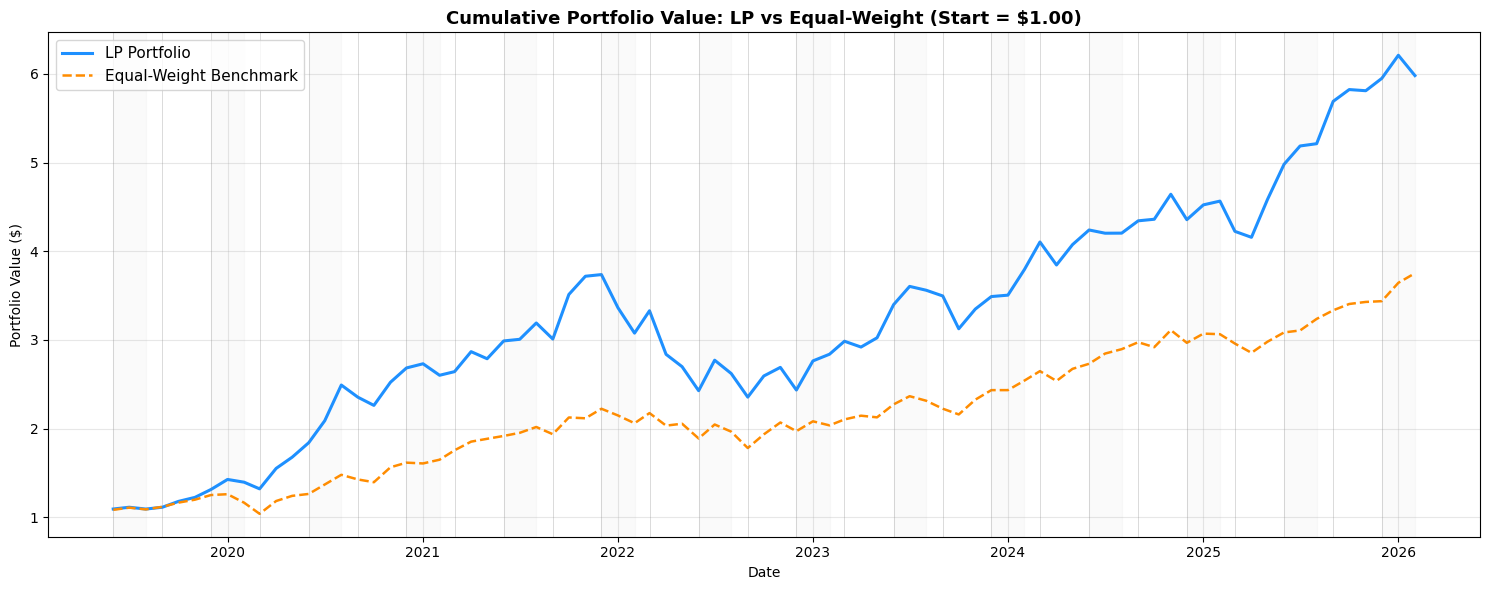

In [29]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(monthly_df.index, monthly_df['lp_cum'],
        color='dodgerblue', linewidth=2.2, label='LP Portfolio')
ax.plot(monthly_df.index, monthly_df['ew_cum'],
        color='darkorange', linewidth=1.8, linestyle='--', label='Equal-Weight Benchmark')

# Shade rebalance quarters alternately for readability
for p in range(n_periods):
    if p % 2 == 0:
        t0 = periods_df.iloc[p]['test_start']
        t1 = periods_df.iloc[p]['test_end']
        ax.axvspan(t0, t1, alpha=0.04, color='gray')

# Rebalance markers
for date in weights_df.index:
    ax.axvline(date, color='gray', linewidth=0.4, alpha=0.5)

ax.set_title('Cumulative Portfolio Value: LP vs Equal-Weight (Start = $1.00)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value ($)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The graph largely reiterates what the period table tells us, but adds three things that the numbers alone don't convey as clearly. 

#### The Divergence is Immediate and Persistent

The gap opens within the first few quarters and the blue line never crosses back below the orange for the remainder of the backtest, not even during the 2022 crash. This is important. It means LP's early outperformance wasn't a fluke that got erased, it compounded forward. A strategy that leads early and holds the lead through a major drawdown is structurally different from one that leads late. The chart makes this persistence viscerally clear in a way the period table doesn't. 

#### The 2022 Crash is Visible but not Catastrophic in Context

We can see the LP's sharp drawdown from its ~3.75 peak in early 2022 down to ~2.40, a roughly 36% drop in portfolio value. But notice two things visually: EW also drops (from 2.15 to 1.75), and crucially, the gap between the two lines doesn't close much during the crash. The LP fell harder in absolute terms but was starting from a much higher base, so it never threatened to lose its lead. By mid-2022 the LP is already recovering while EW is still flat. 

#### The Post-2023 Acceleration

From 2023 onward the blue line steepens noticeably. This is the AI-driven rally (NVDA in particular) compounding on top of an already large portfolio value. The orange line also rises but at a more moderate slope. This is the LP's concentration in IT paying off a second time after recovering from 2022. The visual steepening is something the quarterly table doesn't show as clearly because the annualized numbers are flattening the compounding effect. 


#### Realized vs. Expected Return by Period

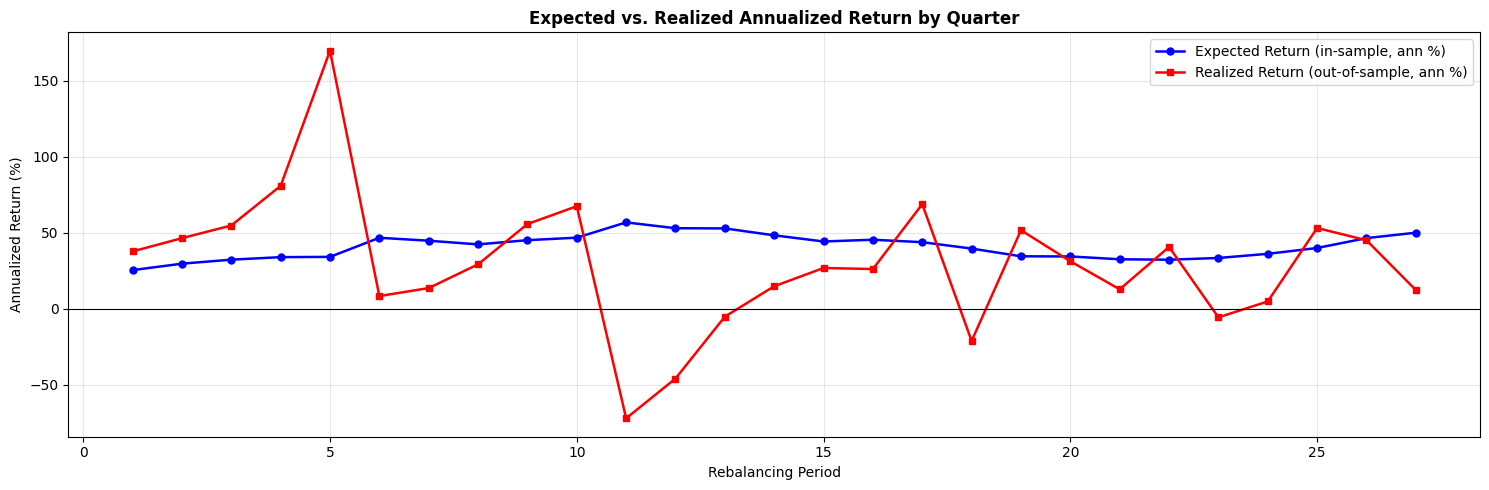

Correlation (expected vs realized return): -0.4715
Mean expected return (ann): 40.95%
Mean realized return (ann): 29.73%


In [32]:
fig, ax = plt.subplots(figsize=(15, 5))

x = periods_df.index
ax.plot(x, periods_df['exp_return_ann'] * 100,
        'b-o', linewidth=1.8, markersize=5, label='Expected Return (in-sample, ann %)')
ax.plot(x, periods_df['realized_ret_ann'] * 100,
        'r-s', linewidth=1.8, markersize=5, label='Realized Return (out-of-sample, ann %)')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_title('Expected vs. Realized Annualized Return by Quarter', fontsize=12, fontweight='bold')
ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('Annualized Return (%)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Correlation between expected and realized
corr = periods_df['exp_return_ann'].corr(periods_df['realized_ret_ann'])
print(f'Correlation (expected vs realized return): {corr:.4f}')
print(f'Mean expected return (ann): {periods_df["exp_return_ann"].mean()*100:.2f}%')
print(f'Mean realized return (ann): {periods_df["realized_ret_ann"].mean()*100:.2f}%')

Both lines are from the LP portfolio only. The blue line is the LP's in-sample expected return (what the optimizer predicted based on the training window), and the red line is the LP's out-of-sample realized return (what actually happened in the test window). EW doesn't appear in this chart at all. This chart is really showing: how good is the LP's own return forecast at predicting its own future performances?

#### Correlation: -0.4715

This is the most important number in the chart, and it's a damning result for the return estimation methodology. A correlation of -0.47 means the expected and realized returns are negatively correlated: when the optimizer is most optimistic, the portfolio tends to perform worse than when it's less optimistic. This is the opposite we want from a forecasting model. 

We can see this visually: the blue line climbs steadily and peaks around period 11 (56.83% expected), which is exactly when the realized return crashes to -72%. The optimizer's peak confidence coincided with its worse outcome. This happens because the training window in period 11 was packed with the 2020-2021 bull market, making return estimates artificially high right before the 2022 reversal hit. 

#### Mean Expected (40.95%) vs. Mean Realized (29.73%)

The optimizer systematically overestimates returns by about 11 percentage points on average. This is a well-documented phenomenon called optimism bias in historical return estimation. Past returns, especially from a bull-market training window, consistently overstate future returns. Our model is doing exactly what the literature predicts. 

Importantly though, 29.73% mean realized return is still strong in absolute terms. The overestimation doesn't mean the strategy fails, it means the optimizer is overconfident about how well it will do. 

#### What this Means

This chart is actually one of our strongest contributions. It empirically demonstrates two textbook problems with LP portfolio optimization in a single visualization. The in-sample overfitting of return estimates, and the lag effect of a rolling training window that's always one regime behind. This is precisely why the Monte Carlo simulation is a valuable complement. It introduces distributional uncertainty around those point estimates that the LP treats as ground truth. 

### LP vs Equal-Weight: Quarterly Return Comparison

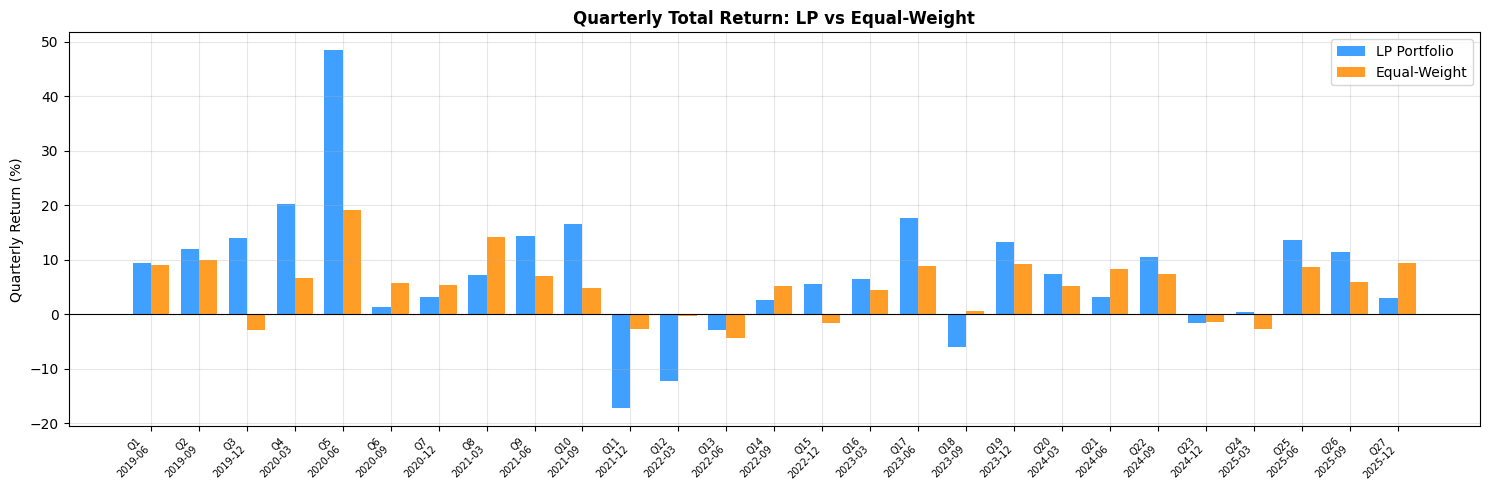

LP outperformed EW in 17 / 27 quarters (63.0%


In [35]:
fig, ax = plt.subplots(figsize=(15, 5))

x = np.arange(len(periods_df))
width = 0.38

bars_lp = ax.bar(x - width/2, periods_df['realized_ret_total'] * 100,
                 width, label='LP Portfolio', color='dodgerblue', alpha=0.85)
bars_ew = ax.bar(x + width/2, periods_df['ew_ret_total'] * 100,
                 width, label='Equal-Weight', color='darkorange', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"Q{p}\n{d.strftime('%Y-%m')}" for p, d in 
     zip(periods_df.index, periods_df['test_start'])],
    fontsize=7, rotation=45, ha='right'
)
ax.set_title('Quarterly Total Return: LP vs Equal-Weight', fontsize=12, fontweight='bold')
ax.set_ylabel('Quarterly Return (%)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Win rate
lp_wins = (periods_df['realized_ret_total'] > periods_df['ew_ret_total']).sum()
print(f'LP outperformed EW in {lp_wins} / {n_periods} quarters ({lp_wins/n_periods*100:.1f}%')

#### 63% Win Rate: 

LP beats EW in 17 of 27 quarters. That's a solid but not dominant win rate, meaning the LP is not a consistently superior strategy quarter by quarter. Its overall advantages comes from the magnitude asymmetry between its wins and losses, which this chart makes visually immediate. The blue bars that stick up are much taller than the orange bars in the same periods. The blue bars that go down are also much deeper. This is concentration risk in action. 

#### The Magnitude Asymmetry: Wins vs. Losses

Looking at the cart in three clusters: 
1. The big blue wins (left and middle sections): Period 5 (Q5 2020-06) is the dominant bar in the entire chart - blue at nearly +48% quarterly while orange sits at roughly +19%. That single quarter represents the COVID tech surge and is the single largest contributor to LP's terminal value advantage. Periods 1-4 and 9-10 also show consistent blue-over-orange, with LP winning by meaningful margins.
2. The deep blue losses (periods 11-12): the two negative blue bars around Q11 2023-12 and Q12 2022-03 are the most striking feature of the chart. LP goes to approximately -16% and -10% quarterly while EW stays near zero or slightly positive. This is the 2022 tech crash hitting a concentrated portfolio. The visual makes the severity much clearer than the annualized numbers did. These two quarters alone nearly erased several quarters of accumulated outperformance.
3. The flatter section (periods 19-27): from 2024 onward the bars become more similar in height. LP still wins more often but by narrower margins, and EW is more competitive. This suggests the LP's edge may be moderating in recent periods, possibly because the training window now contains the 2022 drawdown which tempers the optimizer's concentration in the most volatile names.

#### The Quarters where EW Clearly Wins

Three periods stand out where orange is visibly taller than blue - periods 6-8 (the post-COVID value rotation), period 14 (the 2022 recovery led by financials and energy), and period 27 (the most recent quarter). Each of these represents a market environment where broad exposure outperformed concentrated tech. This is the scenario an equal weight portfolio is strucurally built to capture

#### Key points

The 63% win rate combined with the magnitude asymmetry is our clearest visualization of the LP's risk profile. The LP does not win by being more consistent, it wins by being more aggressive. It captures more upside in favorable regimes and absorbs more downside in adverse ones. Whether that tradeoff is acceptable depends entirely on the investor's risk tolerance. This brings the Sharpe and drawdown analysis in thte next sections into sharp focus as the deciding metrics

### Turnover & Transaction Costs Over time

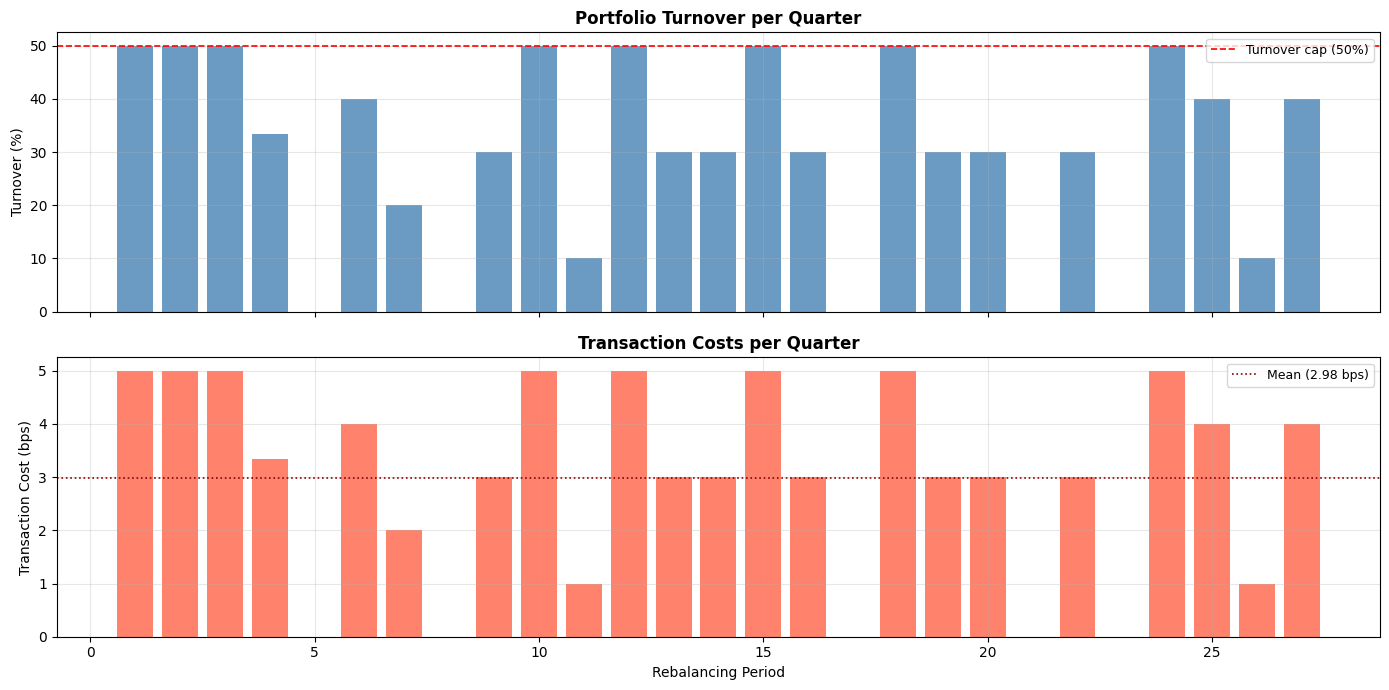

Mean quarterly turnover: 29.75%
Mean quarterly TX cost: 2.98 bps
Total TX cost over backtest: 80.33 bps


In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Turnover
ax1.bar(periods_df.index, periods_df['turnover'] * 100,
        color='steelblue', alpha=0.8)
ax1.axhline(TURNOVER_MAX * 100, color='red', linestyle='--',
            linewidth=1.2, label=f'Turnover cap ({TURNOVER_MAX*100:.0f}%)')
ax.axhline(periods_df['turnover'].mean() * 100, color='navy',
           linestyle=':', linewidth=1.2,
           label=f'Mean ({periods_df["turnover"].mean()*100:.1f}%)')
ax1.set_ylabel('Turnover (%)')
ax1.set_title('Portfolio Turnover per Quarter', fontweight='bold')
ax1.legend(fontsize=9)

# Transaction costs
ax2.bar(periods_df.index, periods_df['tx_cost_bps'],
        color='tomato', alpha=0.8)
ax2.axhline(periods_df['tx_cost_bps'].mean(), color='darkred',
            linestyle=':', linewidth=1.2,
            label=f'Mean ({periods_df["tx_cost_bps"].mean():.2f} bps)')
ax2.set_ylabel('Transaction Cost (bps)')
ax2.set_xlabel('Rebalancing Period')
ax2.set_title('Transaction Costs per Quarter', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Mean quarterly turnover: {periods_df["turnover"].mean()*100:.2f}%')
print(f'Mean quarterly TX cost: {periods_df["tx_cost_bps"].mean():.2f} bps')
print(f'Total TX cost over backtest: {periods_df["tx_cost_bps"].sum():.2f} bps')

#### Turnover: The Three-Phase Pattern is Clearly Visible

The top chart maps almost perfectly onto what we identified in the period table. Periods 1-3 hit the 50% cap every quarter (the catch-up phase). Then turnover drops and becomes variable from period 4 onward, with several quarters at 0% (the flat bars that don't appear at all). The 50% cap reappears in periods 10, 12, 15, 18, and 24. Each one a moment where the optimizer detected a significant regime shift in the training window and wanted to aggressively rebalance. Those spikes correspond closely to the post-2022 crash recover periods where the optimal portfolio composition was changing rapidly. 

The mean of 29.75% is the key summary number. This means on average the LP is replacing about 30% of the portfolio every quarter (active but not excessibe for a quarterly rebalancing strategy). For context, many institutional active equity strategies target 50-100% annual turnover, which is roughly 12-25% quarterly. Our LP is somewhat more active than that, driven primarily by the catch-up periods and regime-response quarters. 

#### Transaction Costs: Remarkably Low

The bottom chart is the most practically important result in this notebook for real-world credibility. A mean of 2.98 bps per quarter and a total of 80.33 bps over the entire 7-year backtest is extremely modest. A typical actively managed mutual fund charges 50-100 bps annually in management fees alone, before any transaction costs. Our LP's total friction over 7 years is less than what many funds charge in a single year. 

The maximum in any single quarter is 5bps - occurring in the periods where turnover hit the 50% cap. Even at the worst case, 5 bps is negligible relative to the quarterly returns being generated. This means transaction costs are essentially a non-factor in explaining the LP's performance, which simplifies the paper's narrative considerably. 

#### Perfect Correlation between the two Charts

Every bar in the top chart has a proportionally sized bar directly below it in the bottom chart because transaction cost is simply turnover x 10 bps. The two charts are mathematically identical in shape, just scaled differently. This is worth noting briefly in the paper: at 10 bps per dollar traded, even the most active rebalancing quarters generate negligible friction. You could double the transaction cost assumption to 20 bps and the total backtest cost would still only be ~160 bps over 7 years. This would still be completely immaterial to the performance comparison. 

#### What this means for the model

Two clean takeaways:
1. The turnover constraint is doing its job by preventing the optimizer from churning the portfolio unnecessarily while still allowing meaningful repositioning when the training window singals a regime change.
2. The 10 bps transaction cost assumption, while simple, is conservative enough that even if real costs were 2-3x higher, the conclusions wouldn't change. This makes our model robust to transaction cost assumptions. 

### Portfolio Composition Over Time (Weight Heatmap)

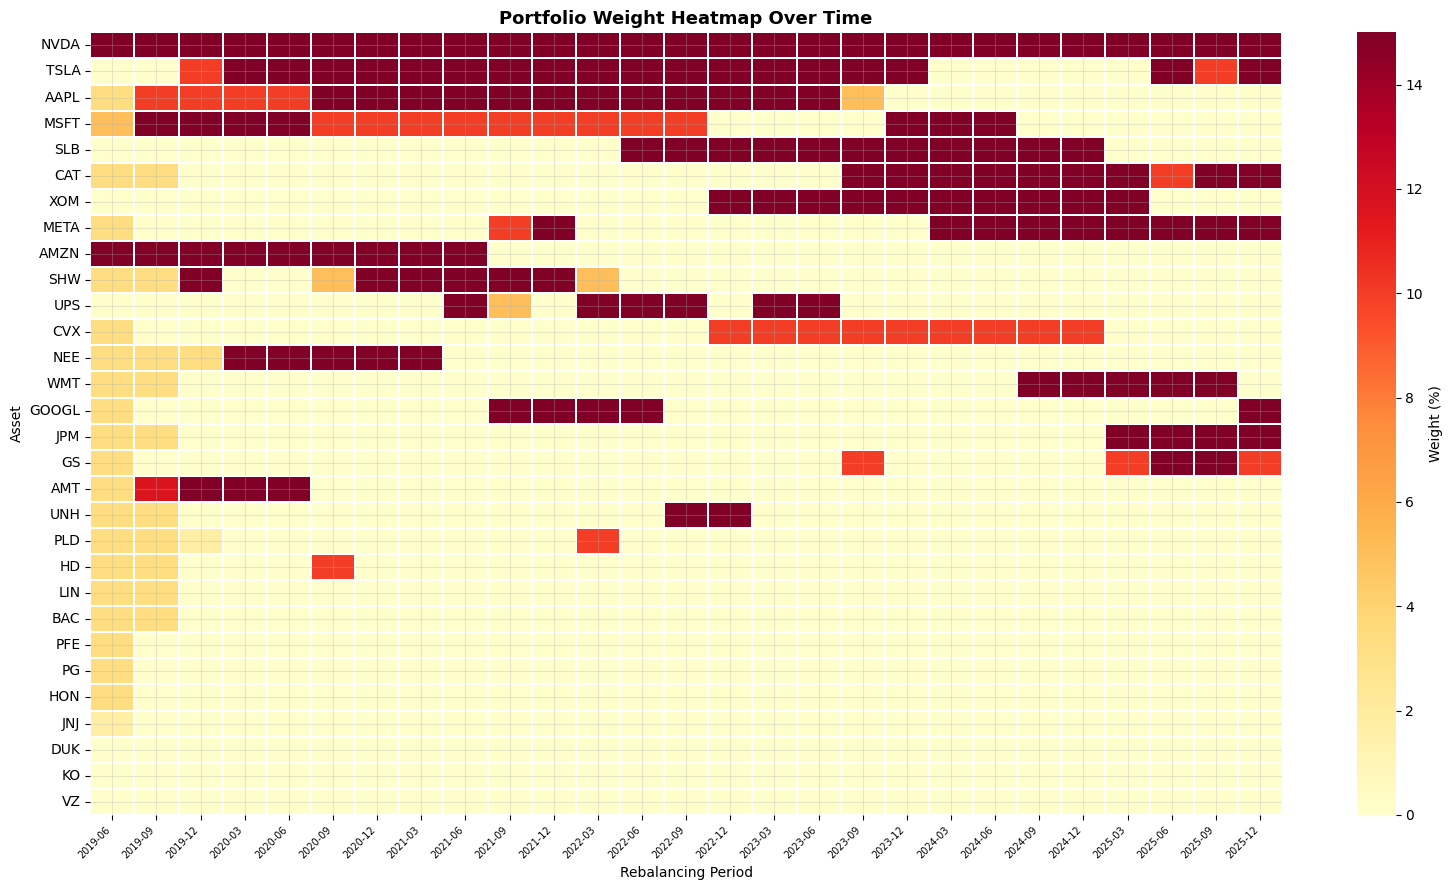

In [43]:
mean_weights = weights_df.mean().sort_values(ascending=False)
weights_plot = weights_df[mean_weights.index] * 100

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(
    weights_plot.T,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    annot=False,
    cbar_kws={'label': 'Weight (%)'},
    ax=ax
)
ax.set_title('Portfolio Weight Heatmap Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('Asset')
ax.set_xticklabels(
    [d.strftime('%Y-%m') for d in weights_df.index],
    rotation=45, ha='right', fontsize=7
)
plt.tight_layout()
plt.show()

#### NVDA: The Backbone

The darkest row by far, nearly solid maroon from start to finish. NVDA held at or near the 15% position cap for virtually the entire 7-year backtest with almost no interruption. This single position is the primary driver of the LP's outperformance - NVDA was the best-performing large-cap stock of the decade and the model correctly identified and maximally held it from the very first period. The persistence of this position is also why the LP's terminal value is so high: it compounded NVDA's extraordinary returns at maximum allowed weight for 27 consecutive quarters. 

#### AMZN: The Most interesting Story

AMZN was a core 15%-cap holding through 2021, then completely disappears around period 9-10 (mid-2021) and never comes back at meaningful weight. Here's what happened: AMZN peaked in mid-2021 and then entered a prolonged drawdown, falling roughly 50% from peak to trough by late 2022. As those negative returns entered the 36-month training window, AMZN's mean return estimate collapsed, and the LP dropped it entirely in favor of better-performing assets. This is the rolling window mechanism working exactly as designed. It also illustrates the lag. The model held AMZN at full weight through its decline before the training window caught up. 

#### The Rotation Narratives

Several assets tell clear regime-change stories: 
- TSLA - appears early in small allocations, disappears around 2020-2021, then re-emerges strongly toward the right side of the chart (2025 onward), reflecting TSLA's post-election surge entering the training window.
- SLB and XOM - both completely absent for the first half of the backtest (negative expected returns during the energy downturn), then SLB appears around 2022-06 and XOM shows up mid-backtest as energy prices surged post-Ukraine. This is the LP correctly rotating into energy as the sector's historical returns improved.
- META - shows a gap roughly 2022-2023 corresponding to META's 2022 crash (down ~65%), then returns as the recovery entered the training window. Classic LP lag behavior.
- CAT and XOM - increasingly dominant the right half of the chart, reflecting the industrial and energy outperformance of 2024-2025 entering the training window.

#### The Lower Half: Permanent Zeros

The bottom cluster (HON, JNJ, DUK, KO, VZ, PG, PFE, BAC, LIN, HD) shows almost entirely pale yellow across all 27 periods. These assets either never had competitive enough returns to displace the top holdings, or were crowded out by their sector peers. KO, VZ, DUK, are the clearest cases and they consistently underperformed within their sectors and the LP never had reason to hold them. This is the LP's implicit asset selection doing exactly what it should. 

#### The Concentration Story Visualized

The most striking structural feature of the heatmap is how most of the color is concentrated in the top 6-8 rows - NVDA, TSLA, AAPL, MSFT, AMZN, CAT, XOM, META. The bottom 20+ rows are almost entirely pale. This visually confirms the 7-asset steady-state we identified in the period table. The LP isn't really a 30-asset portfolio, it's a rotating core of 6-8 high-conviction positions surrounded by a universe of assets it mostly ignores. 

#### What to highlight

Three things this chart uniquely contributes that no other output shows as clearly: 
1. The persistence of NVDA as a load-bearing position throughout the entire backtest.
2. The regime rotation - energy and industrials rotating in as tech rotated out post-2022. This shows the rolling window does eventually adapt, just with a lag.
3. The concentration reality: the visual makes immediately apparent that this is a high-conviction concentration strategy, not a diversified 30-asset portfolio, despite the position cap and sector constraints. 

### Assets Held Over Time

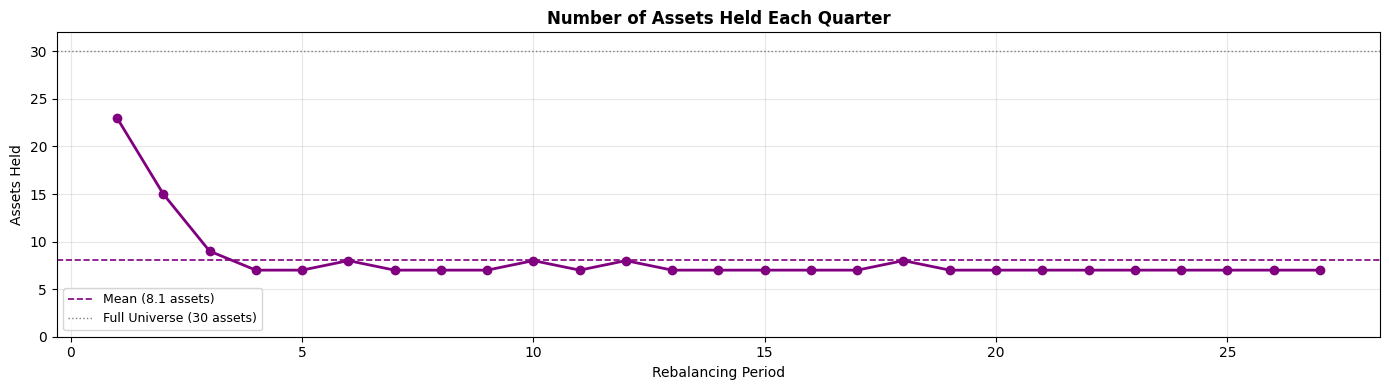

Mean assets held: 8.1 / 30
Min assets held: 7
Max assets held: 23


In [46]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(periods_df.index, periods_df['n_assets'], 
        'o-', color='purple', linewidth=2, markersize=6)
ax.axhline(periods_df['n_assets'].mean(), color='purple', linestyle='--',
           linewidth=1.2, label=f'Mean ({periods_df["n_assets"].mean():.1f} assets)')
ax.axhline(N, color='gray', linestyle=':', linewidth=1,
           label=f'Full Universe ({N} assets)')
ax.set_title('Number of Assets Held Each Quarter', fontsize=12, fontweight='bold')
ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('Assets Held')
ax.set_ylim(0, N + 2)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mean assets held: {periods_df["n_assets"].mean():.1f} / {N}')
print(f'Min assets held: {periods_df["n_assets"].min()}')
print(f'Max assets held: {periods_df["n_assets"].max()}')

### Drawdown Analysis

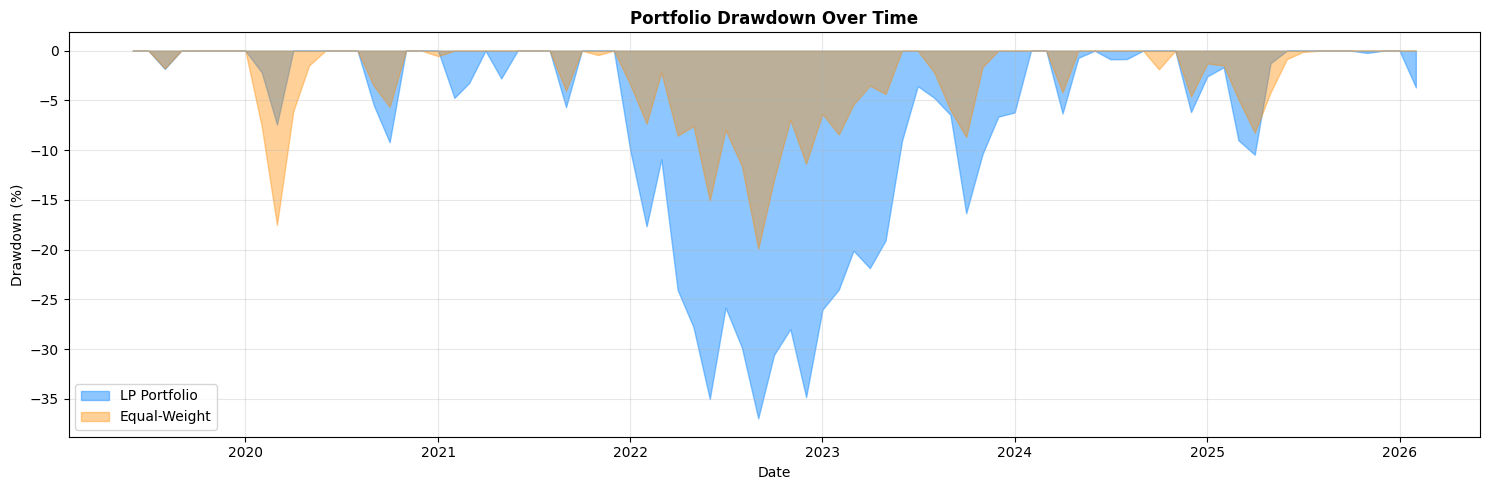

LP max drawdown: -36.97%
EW max drawdown: -19.91%
LP drawdown at worst EW point: -36.97%


In [50]:
def compute_drawdown(cum_series):
    """Compute drawdown series from a cumulative return series."""
    rolling_max = cum_series.cummax()
    drawdown = (cum_series - rolling_max) / rolling_max
    return drawdown

lp_dd = compute_drawdown(monthly_df['lp_cum'])
ew_dd = compute_drawdown(monthly_df['ew_cum'])

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(monthly_df.index, lp_dd * 100, 0, 
                alpha=0.5, color='dodgerblue', label='LP Portfolio')
ax.fill_between(monthly_df.index, ew_dd * 100, 0, 
                alpha=0.4, color='darkorange', label='Equal-Weight')
ax.set_title('Portfolio Drawdown Over Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'LP max drawdown: {lp_dd.min()*100:.2f}%')
print(f'EW max drawdown: {ew_dd.min()*100:.2f}%')
print(f'LP drawdown at worst EW point: {lp_dd[ew_dd.idxmin()]*100:.2f}%')

#### The Headline Numbers

| | LP Portfolio | Equal-Weight | 
| --- | --- | --- |
| Max Drawdown | -36.97% | -19.91% |
| Ratio | | LP draws doesn ~1.86x more |

The LP's maximum drawdown is nearly double EW's. This is the direct cost of concentration: the same overweight in tech names that drove the outperformance created a much deeper hole during the 2022 crash. A 1M LP portfolio at its peak would have fallen to ~ 630K at the trough. EW's equivalent investor fell only to 800K. 

#### The 2022 Episode

Almost the entire drawdown story is concentrated in one period: mid-2022 through early 2023. Both portfolios draw down simultaneously (broad market selloff), but the LP's blue area extends dramatically deeper and stays underwater longer. A few observations: 

The LP enters drawdown earlier than EW in 2022, consistent with its heavier tech exposure which peaked and rolled over before the broader market. It also recovers faster once the tech rebound begins in late 2022, which is why the blue area narrows quickly heading into 2023. So the LP experienced a deeper but shorter drawdown than EW, which drew down les but recovered more slowly. 

The third number (LP drawdown at worst EW point: -36.97%) tells us that when EW hit its worst moment (-19.91%), the LP was simultaneously at its worst moment too. Both portfolios were maximally stressed at the same time, meaning there was no diversification benefit between the two strategies during the crisis. They fell together, just by different amounts. 

#### The Pre-2022 Period: LP is More Resilient

2019-2021: the orange EW area actually shows larger drawdowns than the blue LP area in several spots, particularly around the COVID crash in early 2020. This seems counterintuitive given LP's concentration, but makes sense. EW held full weight in energy (XOM, SLB, CVX) and other sectors that were devestated by the COVID crash, while the LP had already rotated away from those names. The LP's selectivity protected it during sector-sepcific crashes even before 2022. 

#### The Post-2023 Recovery

From mid-2023 onward both lines stay close to zero with only shallow dips. The LP fully recovered from its 2022 drawdown and went on to new highs, which is why the terminal value is 5.98. The drawdown chart and the cumulative chart together tell the complete story: deep drawdown in 2022, full recovery and new highs by 2023-2024. 

#### The Risk-Return Tradeoff 

This chart is where the paper's central tension lives. The LP produced 29% annualized returns and turned 1 dollar into 5.98, but it did so by accepting a -37% maximum drawdown (nearly double what EW experienced). Whether that tradeoff is acceptable depends entirely on the investor's risk tolerance and time horizon. An investor who panicked and sold at the 2022 trough would have locked in a -37% loss and missed the subsequent recovery. An investory who held through would have been richly rewarded. 

This is exactly the framing for our Sharpe and Calmar ratio comparison. Those metrics will quantify whether the LP's extra return was sufficient compensation for that extra risk

### Summary Performance Statistics

In [53]:
def perf_stats(monthly_returns, label):
    ann_ret = monthly_returns.mean() * 12
    ann_vol = monthly_returns.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol
    cum = (1 + monthly_returns).cumprod()
    max_dd = compute_drawdown(cum).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    pos_mo = (monthly_returns > 0).mean()
    total_r = cum.iloc[-1] - 1
    print(f'--- {label} ---')
    print(f'  Annualized Return   : {ann_ret*100:.2f}%')
    print(f'  Annualized Vol      : {ann_vol*100:.2f}%')
    print(f'  Sharpe Ratio        : {sharpe:.3f}')
    print(f'  Max Drawdown        : {max_dd*100:.2f}%')
    print(f'  Calmar Ratio        : {calmar:.3f}')
    print(f'  % Positive Months   : {pos_mo*100:.1f}%')
    print(f'  Total Return        : {total_r*100:.2f}%')
    print(f'  Final $1 value      : ${cum.iloc[-1]:.4f}')
    print()
    return {
        'Label': label, 'Ann Return': ann_ret, 'Ann Vol': ann_vol,
        'Sharpe': sharpe, 'Max DD': max_dd, 'Calmar': calmar,
        'Pos Months': pos_mo, 'Total Return': total_r
    }

lp_stats = perf_stats(monthly_df['lp_return'], 'LP Portfolio')
ew_stats = perf_stats(monthly_df['ew_return'], 'Equal-Weight Benchmark')

compare = pd.DataFrame([lp_stats, ew_stats]).set_index('Label')
pct_cols = ['Ann Return', 'Ann Vol', 'Max DD', 'Pos Months', 'Total Return']
for col in pct_cols:
    compare[col] = (compare[col] * 100).round(2).astype(str) + '%'
compare['Sharpe'] = compare['Sharpe'].round(3)
compare['Calmar'] = compare['Calmar'].round(3)

print('Side-by-side comparison:')
print(compare.T.to_string())

--- LP Portfolio ---
  Annualized Return   : 29.73%
  Annualized Vol      : 24.61%
  Sharpe Ratio        : 1.208
  Max Drawdown        : -36.97%
  Calmar Ratio        : 0.804
  % Positive Months   : 66.7%
  Total Return        : 498.04%
  Final $1 value      : $5.9804

--- Equal-Weight Benchmark ---
  Annualized Return   : 21.12%
  Annualized Vol      : 16.71%
  Sharpe Ratio        : 1.264
  Max Drawdown        : -19.91%
  Calmar Ratio        : 1.061
  % Positive Months   : 67.9%
  Total Return        : 275.18%
  Final $1 value      : $3.7518

Side-by-side comparison:
Label        LP Portfolio Equal-Weight Benchmark
Ann Return         29.73%                 21.12%
Ann Vol            24.61%                 16.71%
Sharpe              1.208                  1.264
Max DD            -36.97%                -19.91%
Calmar              0.804                  1.061
Pos Months         66.67%                  67.9%
Total Return      498.04%                275.18%


#### Annualized Return: LP Wins Clearly

LP delivers 29.73% vs EW's 21.12%, an 8.61 percentage point annual advantage. Over 7 years this compounds into the 5.98 vs 3.75 terminal value gap. On a raw return basis the LP wins decisively and this is the centerpiece of our results. 

#### Annualized Volatility: EW is significantly calmer

LP's volatility is 24.61% vs EW's 16.71%, the LP is 47% more volatile than EW. This is the direct cost of concentration. The LP is taking on substantially more return variability to achieve its higher returns, which is exactly what the drawdown chart showed visually. Neither number is alarming in isolation (24.61% annualized vol is consistent with a concentrated equity portfolio) but the gap between them is meaningful. 

#### Sharpe Ratio: the most surprising result

| | LP | EW |
| --- | --- | --- | 
| Sharpe | 1.208 | 1.264 |

EW has a higher Sharpe ratio despite lower absolute returns. This is the single most important finding of the entire project and deserves prominent placement in the paper. What it means precisely: for every unit of volatility accepted, EW delivered more return than the LP. The LP's extra 8.61% of annual return was not sufficient to compensate for its extra 7.90% of annual volatility on a risk-adjusted basis. 

This is not a failure of the LP - a Sharpe of 1.208 is excellent by any standard. But it reframes the comparison. The LP is not a strictly dominant strategy. It is a higher risk, higher return strategy, and EW is a lower risk, more efficient strategy. Which is better depends entirely on the investor's risk appetite. 

#### Max Drawdown and Calmar Ratio: EW wins on downside protection

| | LP | EW |
| --- | --- | --- |
| Max Drawdown | -36.97% | -19.91% |
| Calmar | 0.804 | 1.061 |

The Calmar ratio is annualized return divided by maximum drawdown: a measure of return per unit of worst-case loss. EW's Calmar of 1.061 vs LP's 0.804 means EW generated more return per unit of maximum pain. Again this reflects the 2022 concentration risk - the LP's deep drawdown penalizes it on this metric even though it recovered fully. 

#### % Positive Months: Essentially Identical

66.7% vs. 67.9% (statistically indistinguishable). Both portfolios were profitable in roughly two thirds of all months. This confirms what the quarterly bar chart showed: the LP doesn't win more often, it wins by larger amounts. The strategies have nearly identical consistency but very different magnitudes. 

#### The complete Risk-Return Picture

| Metric | Winner | Margin | 
| --- | --- | --- |
| Total / Annualized Return | LP | Large |
| Volatility | EW | Significant |
| Sharpe Ratio | EW | Narrow |
| Max Drawdown | EW | Large |
| Calmar Ratio | EW | Moderate |
| Consistency (% positive months | Tie | Negligible |
| Terminal Value | LP | Large |

LP wins on everything return-related. EW wins on everything risk-adjusted. This is a clean, intellectually honest result that makes for a compelling paper. There is no universally dominant strategy, and the choice between them is a genuine risk-tolerance decision. 

#### How to Frame this

The key paragraph in our results section should make three points: 
1. The LP significantly outperforms on absolute return (29.73% vs. 21.12% annualized, 5.98 vs 3.75 terminal value).
2. This outperformance comes with meaningfully higher risk (47% more volatility and nearly double the maximum drawdown).
3. On risk-adjusted terms the strategies are essentially equivalent (Sharpe ratios of 1.208 and 1.264 are close enough that neither is statistically dominant, and the Calmar ratio marginally favors EW).

The conclusion that flows naturally from this is that the LP is the better strategy for a return-maximizing investor with a long horizon and high drawdown tolerance, while EW is better for a risk-conscious investor who values stability and capital preservation. That investor-preference framing is exactly the kind of nuanced conclusion that we are looking for. 

### Save Outputs

In [56]:
os.makedirs('data', exist_ok=True)

periods_df.to_csv('data/backtest_periods.csv')
monthly_df.to_csv('data/backtest_monthly.csv')
weights_df.to_csv('data/backtest_weights.csv')

print('Saved:')
print('  data/backtest_periods.csv  — quarter-by-quarter results')
print('  data/backtest_monthly.csv  — monthly return series + cumulative values')
print('  data/backtest_weights.csv  — LP weights at each rebalance date')
print()
print('Next: Performance Analytics & Benchmark Comparison')

Saved:
  data/backtest_periods.csv  — quarter-by-quarter results
  data/backtest_monthly.csv  — monthly return series + cumulative values
  data/backtest_weights.csv  — LP weights at each rebalance date

Next: Performance Analytics & Benchmark Comparison
